In [1]:
pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.2/537.2 kB 228.1 kB/s eta 0:00:001m? eta -:--:--

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Word Cloud сохранён как 'least_popular_tags_wordcloud.png'


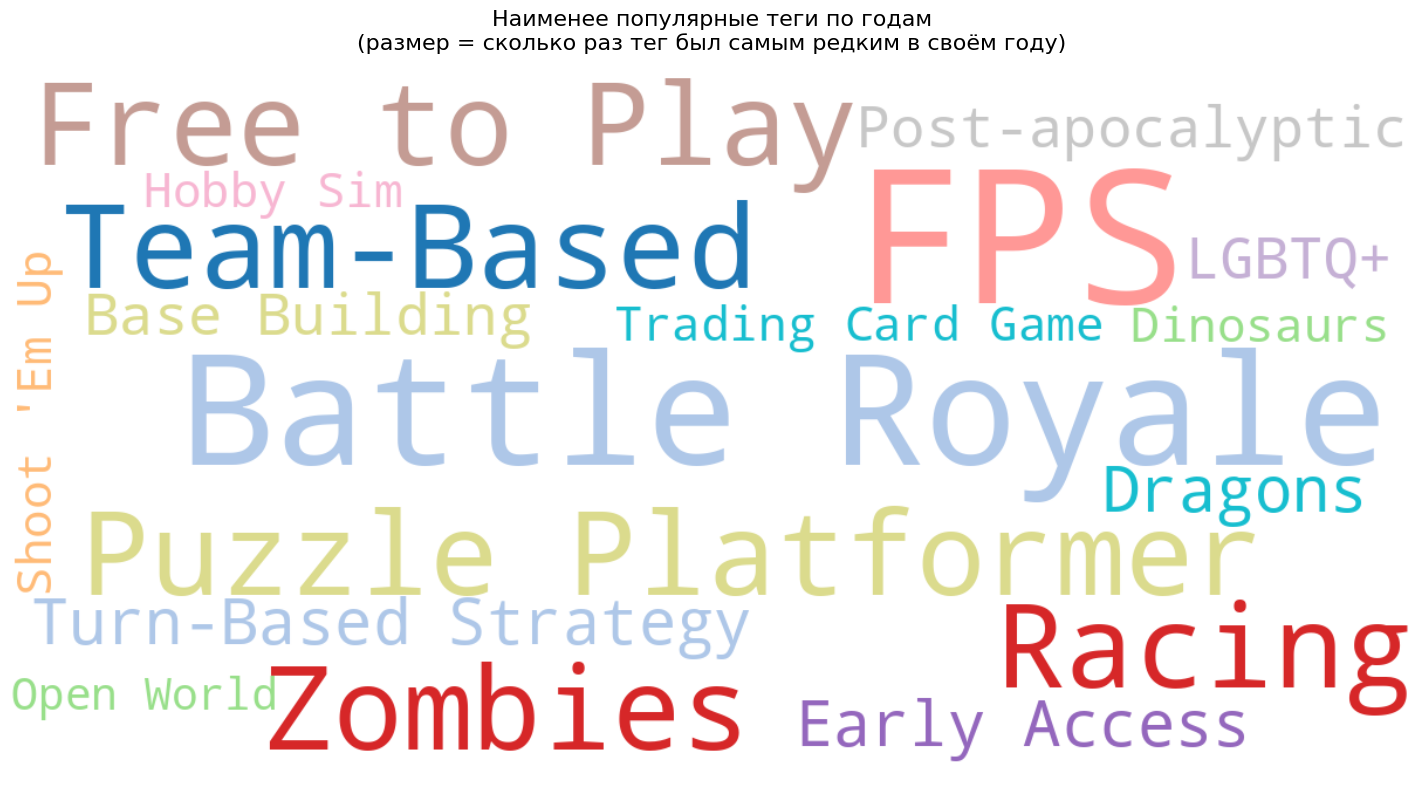

In [2]:
# least_popular_tags_wordcloud
import json
import pandas as pd
from collections import Counter
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt


def parse_year(date_str):
    if not date_str:
        return None
    match = re.search(r'\b(19|20)\d{2}\b', date_str)
    return int(match.group()) if match else None


# 1. Загрузка данных
with open('steam_top_1000.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

data = data[:1000]
df = pd.DataFrame(data)

# 2. Предобработка
df['year'] = df['release_date'].apply(parse_year)
df = df.dropna(subset=['year']).copy()
df['year'] = df['year'].astype(int)
df = df[df['tags'].apply(lambda x: isinstance(x, list) and len(x) > 0)]


# 3. Анализ по годам с корректным определением "наименее популярного" тега
least_popular_tags = []

for year, group in df.groupby('year'):
    if len(group) < 2:
        continue

    all_tags = [tag for tags in group['tags'] for tag in tags]
    if not all_tags:
        continue

    tag_counts = Counter(all_tags)
    if max(tag_counts.values()) == 1:
        continue  # все теги уникальны — пропускаем

    # Топ-3
    most_common = [tag for tag, _ in tag_counts.most_common(3)]
    most_common_set = set(most_common)

    # Остальные теги
    other_tags = {tag: cnt for tag, cnt in tag_counts.items() if tag not in most_common_set}

    if other_tags:
        unique_counts = set(other_tags.values())
        if len(unique_counts) > 1:
            # Есть различие → можно выбрать самый редкий
            min_count = min(other_tags.values())
            least_tag = next(tag for tag, cnt in other_tags.items() if cnt == min_count)
            least_popular_tags.append(least_tag)
        # Если все одинаковы — не добавляем (нет объективного "наименее популярного")
    # Если other_tags пуст — тоже пропускаем


# 4. Построение Word Cloud

# Собираем частоту
freq_dict = Counter(least_popular_tags)

# Генерация облака слов
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='tab20',  # яркие разные цвета
    max_words=100,
    relative_scaling=0.5
).generate_from_frequencies(freq_dict)

# Отображение и сохранение
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Наименее популярные теги по годам\n(размер = сколько раз тег был самым редким в своём году)", 
          fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("least_popular_tags_wordcloud.png", dpi=200, bbox_inches='tight')
print("Word Cloud сохранён как 'least_popular_tags_wordcloud.png'")


 Scatter plot сохранён как 'least_popular_tags_scatter.png'


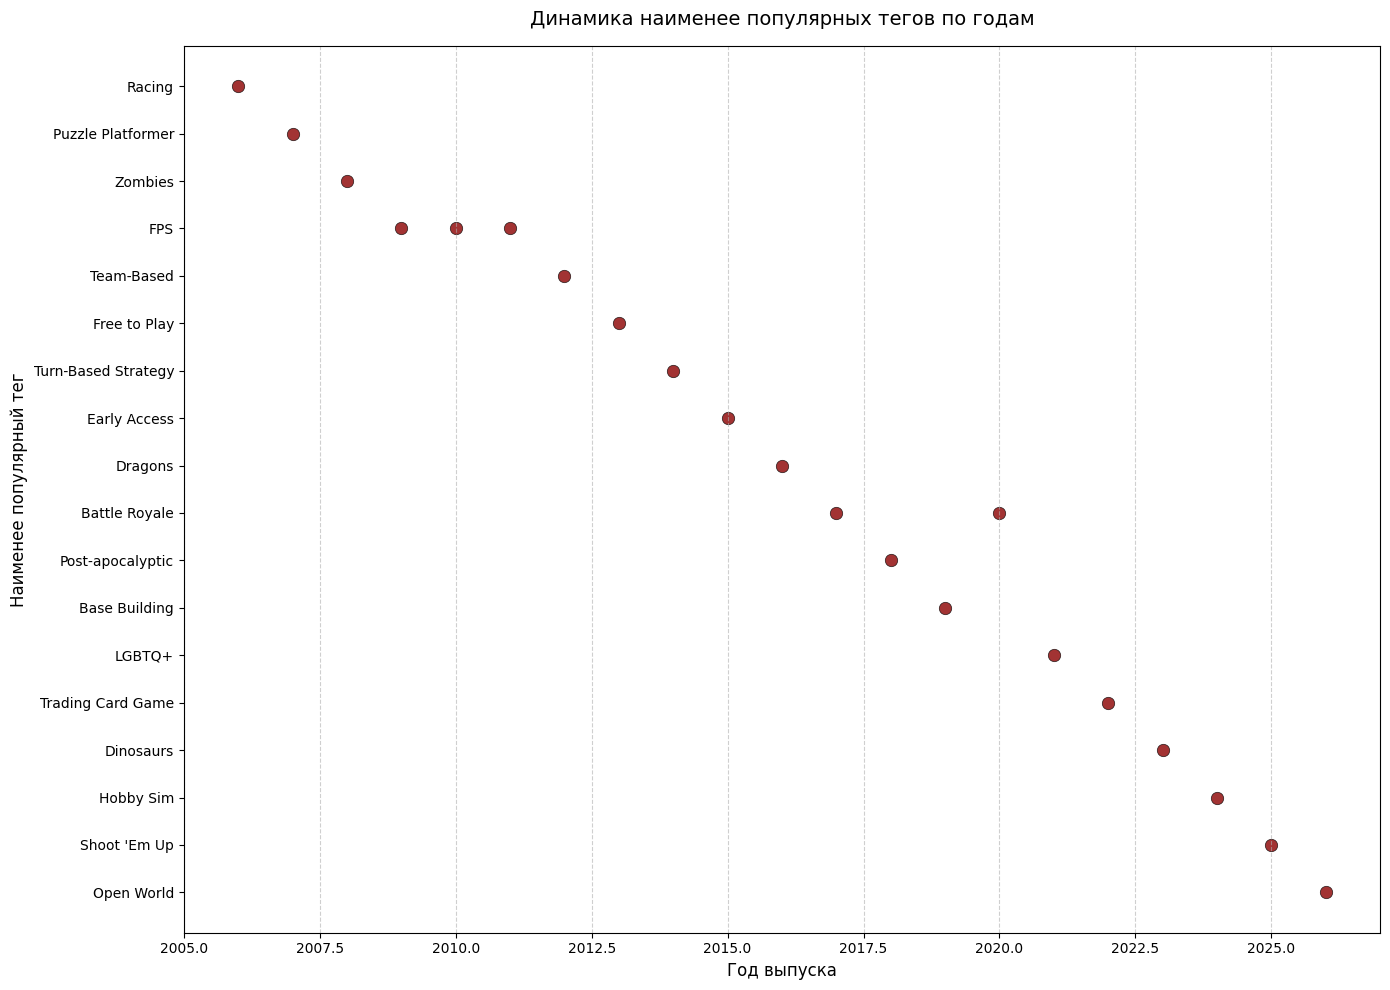

In [4]:
# Построение scatter plot
# Уникальные теги - числовые метки по оси Y
unique_tags = sorted(set(least_tags_list), key=least_tags_list.index)  # сохраняем порядок появления
tag_to_y = {tag: idx for idx, tag in enumerate(unique_tags)}
y_values = [tag_to_y[tag] for tag in least_tags_list]

plt.figure(figsize=(14, 10))
plt.scatter(years_list, y_values, s=80, alpha=0.8, color='darkred', edgecolors='black', linewidth=0.5)

# Настройка осей
plt.yticks(range(len(unique_tags)), unique_tags)
plt.xlabel("Год выпуска", fontsize=12)
plt.ylabel("Наименее популярный тег", fontsize=12)
plt.title("Динамика наименее популярных тегов по годам", fontsize=14, pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()  # опционально: самые новые теги сверху

plt.tight_layout()
plt.savefig("least_popular_tags_scatter.png", dpi=200, bbox_inches='tight')
print(" Scatter plot сохранён как 'least_popular_tags_scatter.png'")
# plt.show()